Made by: Thai Vang, Angel Vasquez

Dataset from: https://www.kaggle.com/code/indermohanbains/knn-customer-classification#about_dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [ ]:
url = 'https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/ML0101ENv3/labs/teleCust1000t.csv'

In [ ]:
df = pd.read_csv(url)
df

,region,tenure,age,marital,address,income,ed,employ,retire,gender,reside,custcat
0,2,13,44,1,9,64.0,4,5,0.0,0,2,1
1,3,11,33,1,7,136.0,5,5,0.0,0,6,4
2,3,68,52,1,24,116.0,1,29,0.0,1,2,3
3,2,33,33,0,12,33.0,2,0,0.0,1,1,1
4,2,23,30,1,9,30.0,1,2,0.0,0,4,3
...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,10,39,0,0,27.0,3,0,0.0,1,3,1
996,1,7,34,0,2,22.0,5,5,0.0,1,1,1
997,3,67,59,0,40,944.0,5,33,0.0,1,1,4
998,3,70,49,0,18,87.0,2,22,0.0,1,1,3


In [ ]:
print("Column names:")
print(df.columns.tolist())
print()

print("Missing values:")
print(df.isnull().sum())
print()

print("Customer category distribution:")
print(df["custcat"].value_counts().sort_index())

Column names:
['region', 'tenure', 'age', 'marital', 'address', 'income', 'ed', 'employ', 'retire', 'gender', 'reside', 'custcat']

Missing values:
region     0
tenure     0
age        0
marital    0
address    0
income     0
ed         0
employ     0
retire     0
gender     0
reside     0
custcat    0
dtype: int64

Customer category distribution:
custcat
1    266
2    217
3    281
4    236
Name: count, dtype: int64


In [ ]:
df.describe()

,region,tenure,age,marital,address,income,ed,employ,retire,gender,reside,custcat
count,1000.0000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.0220,35.526000,41.684000,0.495000,11.551000,77.535000,2.671000,10.987000,0.047000,0.517000,2.331000,2.487000
std,0.8162,21.359812,12.558816,0.500225,10.086681,107.044165,1.222397,10.082087,0.211745,0.499961,1.435793,1.120306
min,1.0000,1.000000,18.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,1.0000,17.000000,32.000000,0.000000,3.000000,29.000000,2.000000,3.000000,0.000000,0.000000,1.000000,1.000000
50%,2.0000,34.000000,40.000000,0.000000,9.000000,47.000000,3.000000,8.000000,0.000000,1.000000,2.000000,3.000000
75%,3.0000,54.000000,51.000000,1.000000,18.000000,83.000000,4.000000,17.000000,0.000000,1.000000,3.000000,3.000000
max,3.0000,72.000000,77.000000,1.000000,55.000000,1668.000000,5.000000,47.000000,1.000000,1.000000,8.000000,4.000000


In [ ]:
#Take dataset and group all rows based on custcast column round 2 decimal
df.groupby("custcat").mean().round(2)

,region,tenure,age,marital,address,income,ed,employ,retire,gender,reside
custcat,,,,,,,,,,,
1,2.09,24.68,39.66,0.42,9.39,54.76,2.36,8.48,0.04,0.51,2.20
2,1.96,43.35,41.79,0.53,12.57,74.83,2.96,10.58,0.03,0.55,2.34
3,2.00,40.08,44.43,0.49,13.38,89.03,2.15,14.31,0.08,0.51,2.23
4,2.03,35.14,40.60,0.55,10.87,92.00,3.37,10.23,0.03,0.51,2.60


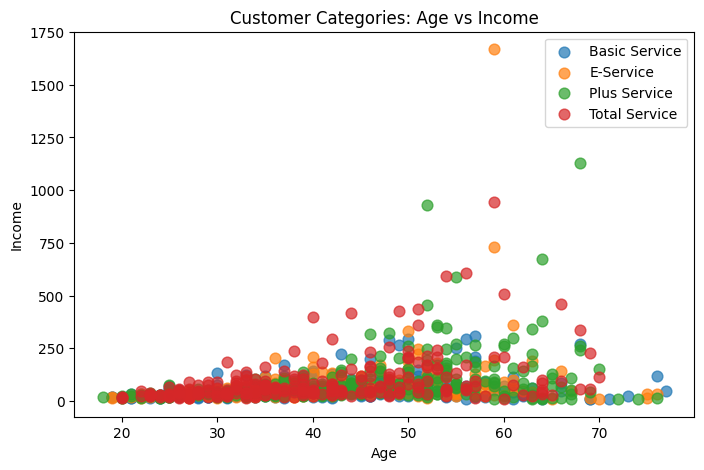

In [ ]:
#scatter plot display
plt.figure(figsize=(8, 5))

#Named categories
category_names = {
    1: "Basic Service",
    2: "E-Service",
    3: "Plus Service",
    4: "Total Service"
}

for category in sorted(df["custcat"].unique()):
    subset = df[df["custcat"] == category]
    plt.scatter(
        subset["age"],
        subset["income"],
        label=category_names[category],  # <-- changed here
        alpha=0.7,
        s=60
    )

plt.xlabel("Age")
plt.ylabel("Income")
plt.title("Customer Categories: Age vs Income")
plt.legend()
plt.show()

In [ ]:
#separate features from labels
feature_columns = [
    'tenure','age','address','income','employ','ed','retire'
]

# X = the input data (all columns within feature_columns)
# y = the labels we want to predict (just the 'custcast' or service levbel column)
X = df[feature_columns]
y = df["custcat"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1000, 7)
Target shape: (1000,)


In [ ]:
#Split and train dataset
# test_size=0.2 means 20% of data goes to testing, 80% to training
# random_state=42 makes the split reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 800
Testing samples: 200


In [ ]:
#Scale the features
scaler = StandardScaler()

# Learn mean & std from training data, then scale it
X_train_scaled = scaler.fit_transform(X_train)

# Scale test data using the SAME mean & std (no new fitting!)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Build and train the KNN model

# Create a KNN classifier with K=7
knn = KNeighborsClassifier(n_neighbors=7)

# Train the model!
knn.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = knn.predict(X_test_scaled)

In [ ]:
# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")
print()

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 37.50%

Classification Report:
              precision    recall  f1-score   support

           1       0.33      0.47      0.39        53
           2       0.37      0.39      0.38        44
           3       0.48      0.43      0.45        56
           4       0.32      0.19      0.24        47

    accuracy                           0.38       200
   macro avg       0.37      0.37      0.36       200
weighted avg       0.38      0.38      0.37       200



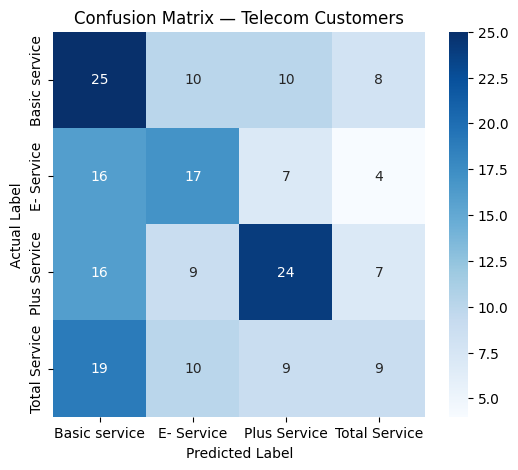

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=[1, 2, 3, 4])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,                           # The confusion matrix data
    annot=True,                   # Show numbers inside cells
    fmt="d",                      # Format as integers (not decimals)
    cmap="Blues",                 # Blue color scheme
    xticklabels= ['Basic service', 'E- Service', 'Plus Service', 'Total Service'],      # Label for predict
    yticklabels= ['Basic service', 'E- Service', 'Plus Service', 'Total Service']       # Labels for actual
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix — Telecom Customers")
plt.show()

In [ ]:
# Finding the best K value using cross validation

#Test K value from ranges 1-30
k_range = range(1, 31)

# For each K, we'll store:
#   - The mean CV accuracy (average across 5 folds)
#   - The std of CV accuracy (how much it varies between folds)

cv_means = []    # Average accuracy
cv_stds = []     # Standard deviation (spread)
cv_means = []
cv_stds = []

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)

    # Run 5-fold cross-validation on the TRAINING data only
    # cross_val_score returns an array of 5 accuracy scores
    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring='accuracy'
    )

    # Store mean and standard deviation
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())

    # Print progess every 5 steps
    if k % 5 == 0 or k == 1:
        print(f"K={k:2d} -> CV Accuracy = {scores.mean():.2%} (+/- {scores.std():.2%})")

K= 1 -> CV Accuracy = 30.63% (+/- 3.09%)
K= 5 -> CV Accuracy = 33.12% (+/- 3.35%)
K=10 -> CV Accuracy = 33.75% (+/- 1.63%)
K=15 -> CV Accuracy = 34.75% (+/- 2.52%)
K=20 -> CV Accuracy = 36.75% (+/- 3.15%)
K=25 -> CV Accuracy = 37.75% (+/- 4.50%)
K=30 -> CV Accuracy = 35.75% (+/- 3.02%)


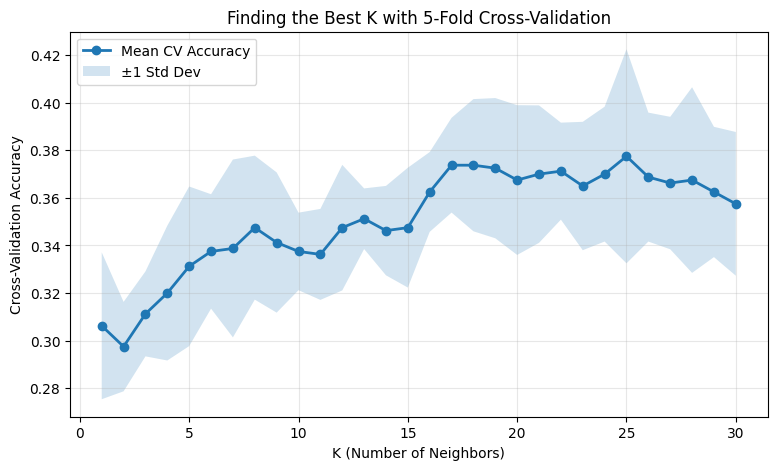

In [ ]:
# Plotting the results
# Convert to numpy arrays for easy math
cv_means = np.array(cv_means)
cv_stds = np.array(cv_stds)
k_list = list(k_range)

plt.figure(figsize=(9, 5))

plt.plot(
    k_list,
    cv_means,
    marker='o',
    linewidth=2,
    label='Mean CV Accuracy'
)

plt.fill_between(
    k_list,
    cv_means - cv_stds,           # Lower bound
    cv_means + cv_stds,           # Upperbound
    alpha=0.2,                    # Transparency
    label='±1 Std Dev'
)

plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Cross-Validation Accuracy")
plt.title("Finding the Best K with 5-Fold Cross-Validation")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Find the best K
best_k = k_list[np.argmax(cv_means)]
best_cv_accuracy = cv_means.max()

print("Best K =", best_k)
print(f"Best CV Accuracy = {best_cv_accuracy:.2%}")

Best K = 25
Best CV Accuracy = 37.75%


In [ ]:
# Retrain with best K and evaluate on test set

# Retrain with best k
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train_scaled, y_train)

#Final rpedictions on test set
y_pred_final = final_model.predict(X_test_scaled)

#final accuracy
final_accuracy = accuracy_score(y_test, y_pred_final)
print(f"Final Test Accuracy (K={best_k}): {final_accuracy:.2%}")
print()

print("Final Classification Report:")
print(classification_report(y_test, y_pred_final))

Final Test Accuracy (K=25): 44.50%

Final Classification Report:
              precision    recall  f1-score   support

           1       0.41      0.45      0.43        53
           2       0.44      0.36      0.40        44
           3       0.41      0.48      0.44        56
           4       0.56      0.47      0.51        47

    accuracy                           0.45       200
   macro avg       0.46      0.44      0.45       200
weighted avg       0.45      0.45      0.45       200



In [ ]:
# Predict on brand new data
new_customer_df = pd.DataFrame({
    "tenure": [12],
    "age": [35],
    "address": [10],
    "income": [55],
    "employ": [8],
    "ed": [3],
    "retire": [0]
})

print("New customer data:")
display(new_customer_df)

new_customer_scaled = scaler.transform(new_customer_df)
prediction = final_model.predict(new_customer_scaled)[0]
probabilities = final_model.predict_proba(new_customer_scaled)[0]

category_names = {
    1: "Basic Service",
    2: "E-Service",
    3: "Plus Service",
    4: "Total Service"
}

print("Predicted Customer Category:", prediction)
print("Category Name:", category_names.get(prediction, "Unknown"))
print()

print("Class Probabilities:")
for class_label, prob in zip(final_model.classes_, probabilities):
    print(f"Category {class_label}: {prob:.2%}")

New customer data:


,tenure,age,address,income,employ,ed,retire
0,12,35,10,55,8,3,0


Predicted Customer Category: 1
Category Name: Basic Service

Class Probabilities:
Category 1: 44.00%
Category 2: 24.00%
Category 3: 16.00%
Category 4: 16.00%


In [ ]:
# New input data for a prediciton
def predict_new_customer():
    new_customer_df = pd.DataFrame({
        "tenure": [float(input("Enter tenure: "))],
        "age": [float(input("Enter age: "))],
        "address": [float(input("Enter years at current address: "))],
        "income": [float(input("Enter income: "))],
        "employ": [float(input("Enter years employed: "))],
        "ed": [int(input("Enter education level: "))],
        "retire": [int(input("Retired? (0=No, 1=Yes): "))]
    })

    new_customer_scaled = scaler.transform(new_customer_df)
    prediction = final_model.predict(new_customer_scaled)[0]
    probabilities = final_model.predict_proba(new_customer_scaled)[0]

    category_names = {
        1: "Basic Service",
        2: "E-Service",
        3: "Plus Service",
        4: "Total Service"
    }

    print()
    print("Predicted Customer Category:", prediction)
    print("Category Name:", category_names.get(prediction, "Unknown"))
    print()

    print("Class Probabilities:")
    for class_label, prob in zip(final_model.classes_, probabilities):
        print(f"Category {class_label}: {prob:.2%}")
predict_new_customer()

Enter tenure: 11
Enter age: 45
Enter years at current address: 7
Enter income: 34454
Enter years employed: 5
Enter education level: 12
Retired? (0=No, 1=Yes): 0

Predicted Customer Category: 3
Category Name: Plus Service

Class Probabilities:
Category 1: 4.00%
Category 2: 16.00%
Category 3: 40.00%
Category 4: 40.00%


# Summary:

To better understand our customer base and improve service targeting, we developed a predictive model that classifies customers into one of four service categories using customer demographic and account information. The model was built using a dataset containing information about 1,000 telecom customers, including variables such as age, income, length of time with the company, employment status, education level, and household characteristics. The goal of the model is to identify which type of service package a customer is most likely to belong to or prefer. The four service categories follows: 1- Basic Service 2- E-Service 3- Plus Service 4- Total Service We used K-Nearest Neighbors (KNN) to perform this classification. In simple terms, the model analyzes customers with similar characteristics and uses those similarities to determine the most likely category for a new customer. If a new customer has demographics and account characteristics similar to a group of existing customers, the model predicts that the new customer will likely fall into the same service category as those similar customers.

To ensure reliable results, the dataset was divided into two groups: a training set, which the model used to learn patterns in the data, and a testing set, which was used to evaluate how well the model performs on customers it has never seen before. We also standardized the input variables to ensure that factors such as income or age did not dominate the distance calculations used by the KNN algorithm.The model was evaluated using several reliability metrics commonly used in data science, including precision, recall, and F1-score. These metrics help measure how accurately the model classifies customers into their correct service categories. We also tested multiple configurations of the model by adjusting the number of neighboring customers used in the decision process. This allowed us to determine the most effective configuration for prediction accuracy.

From a business perspective, this model can be useful in several ways. For example, it can help predict the likely service category for new customers based on their demographic profile. This information could support targeted marketing strategies, personalized service recommendations, or improved customer segmentation. By identifying customers with similar characteristics, the company can also better understand which groups are most likely to prefer certain service packages